# Preprocess movie metadata

Clean and engineer features from `movies_metadata.csv` for clustering and prediction. Save the model-ready table to `data/processed/movies_features.csv`.

## 1. Load metadata

Read the joined Netflix–TMDB movie table.

In [1]:
from pathlib import Path
import ast
import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

ROOT = Path("..")
movies = pd.read_csv(ROOT / "data/processed/movies_metadata.csv")
print(movies.shape)
movies.head(2)

(1806, 25)


,netflix_movie_id,tmdb_id,netflix_title,tmdb_title,year,budget,genres,homepage,keywords,original_language,...,release_date,revenue,runtime,spoken_languages,status,tagline,vote_average,vote_count,cast,crew
0,3,17139,Character,Character,1997.0,4500000,"[{""id"": 18, ""name"": ""Drama""}, {""id"": 10769, ""n...",NaN,"[{""id"": 3683, ""name"": ""law and ethics""}]",nl,...,1997-04-17,0,122.0,"[{""iso_639_1"": ""nl"", ""name"": ""Nederlands""}, {""...",Released,NaN,7.7,25,"[{""cast_id"": 4, ""character"": ""Dreverhaven"", ""c...","[{""credit_id"": ""52fe47099251416c7508bca3"", ""de..."
1,30,6964,Something's Gotta Give,Something's Gotta Give,2003.0,80000000,"[{""id"": 18, ""name"": ""Drama""}, {""id"": 35, ""name...",NaN,"[{""id"": 965, ""name"": ""age difference""}, {""id"":...",en,...,2003-12-12,266728738,128.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,Schmucks are people too.,6.3,410,"[{""cast_id"": 1, ""character"": ""Harry Sanborn"", ...","[{""credit_id"": ""548200699251416e7800666d"", ""de..."


## 2. Drop unused columns and unify title

Remove columns that are sparse, constant, or redundant with ratings we will compute later. Keep a single title (`netflix_title`). Drop free-text `overview` (not used without NLP).

In [2]:
DROP_COLS = [
    "homepage",
    "tagline",
    "keywords",
    "status",
    "popularity",
    "vote_average",
    "vote_count",
    "tmdb_title",
    "original_title",
    "overview",
]

df = movies.drop(columns=DROP_COLS).rename(columns={"netflix_title": "title"})
print(df.shape)
print(list(df.columns))

(1806, 15)
['netflix_movie_id', 'tmdb_id', 'title', 'year', 'budget', 'genres', 'original_language', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'cast', 'crew']


## 3. Remove movies with zero budget, revenue, or runtime

TMDB encodes unknown budget/revenue/runtime as 0. Drop any row where budget, revenue, or runtime is zero so later numeric features use only observed production values.

In [3]:
n_before = len(df)
zero_mask = (df["budget"] == 0) | (df["revenue"] == 0) | (df["runtime"] == 0)
df = df[~zero_mask].copy()
print(f"removed {n_before - len(df)} rows with budget/revenue/runtime == 0; remaining {len(df)}")
print(
    "zeros left - budget:",
    int((df["budget"] == 0).sum()),
    "revenue:",
    int((df["revenue"] == 0).sum()),
    "runtime:",
    int((df["runtime"] == 0).sum()),
)

removed 484 rows with budget/revenue/runtime == 0; remaining 1322
zeros left - budget: 0 revenue: 0 runtime: 0


## 4. Parse JSON fields and extract cast/crew

Parse list-of-dict string columns into name lists. Extract the director and top-3 billed actors.

In [4]:
def parse_names(val):
    if pd.isna(val) or val == "":
        return []
    try:
        obj = ast.literal_eval(val) if isinstance(val, str) else val
    except (ValueError, SyntaxError):
        return []
    if not isinstance(obj, list):
        return []
    return [x.get("name") for x in obj if isinstance(x, dict) and x.get("name")]


def extract_director(crew_str):
    try:
        crew = ast.literal_eval(crew_str) if isinstance(crew_str, str) else crew_str
    except (ValueError, SyntaxError):
        return None
    if not isinstance(crew, list):
        return None
    for person in crew:
        if isinstance(person, dict) and person.get("job") == "Director":
            return person.get("name")
    return None


def extract_top_actors(cast_str, n=3):
    try:
        cast = ast.literal_eval(cast_str) if isinstance(cast_str, str) else cast_str
    except (ValueError, SyntaxError):
        return [None] * n
    if not isinstance(cast, list):
        return [None] * n
    cast_sorted = sorted(
        [c for c in cast if isinstance(c, dict)],
        key=lambda c: c.get("order", 999),
    )
    names = [c.get("name") for c in cast_sorted[:n]]
    return names + [None] * (n - len(names))


df["genre_names"] = df["genres"].map(parse_names)
df["company_names"] = df["production_companies"].map(parse_names)
df["country_names"] = df["production_countries"].map(parse_names)
df["language_names"] = df["spoken_languages"].map(parse_names)
df["director"] = df["crew"].map(extract_director)

actors = df["cast"].map(lambda s: extract_top_actors(s, 3))
df["actor_1"] = actors.map(lambda x: x[0])
df["actor_2"] = actors.map(lambda x: x[1])
df["actor_3"] = actors.map(lambda x: x[2])

print("directors missing:", int(df["director"].isna().sum()))
df[["title", "director", "actor_1", "actor_2", "actor_3"]].head(3)

directors missing: 0


,title,director,actor_1,actor_2,actor_3
1,Something's Gotta Give,Nancy Meyers,Jack Nicholson,Diane Keaton,Keanu Reeves
2,Jade,William Friedkin,David Caruso,Linda Fiorentino,Chazz Palminteri
4,Dragonheart,Rob Cohen,Dennis Quaid,David Thewlis,Pete Postlethwaite


## 5. Numeric features

Apply log1p to budget and revenue, compute log_roi = log1p(revenue) - log1p(budget), add movie_age = 2026 - year, and standardize numeric columns for clustering (*_scaled). No imputation is needed after dropping zero budget/revenue/runtime.

In [5]:
df["budget_log"] = np.log1p(df["budget"])
df["revenue_log"] = np.log1p(df["revenue"])
df["log_roi"] = df["revenue_log"] - df["budget_log"]
df["movie_age"] = 2026 - df["year"]

NUM_COLS = ["budget_log", "revenue_log", "runtime", "year", "log_roi"]
scaler = StandardScaler()
scaled = scaler.fit_transform(df[NUM_COLS])
scaled_df = pd.DataFrame(
    scaled,
    index=df.index,
    columns=[f"{c}_scaled" for c in NUM_COLS],
)
df = pd.concat([df, scaled_df], axis=1)

df[NUM_COLS].describe()

,budget_log,revenue_log,runtime,year,log_roi
count,1322.000000,1322.000000,1322.000000,1322.000000,1322.000000
mean,16.710602,17.513723,112.732980,1993.803328,0.803121
std,1.641761,1.851096,21.765121,12.897631,1.582214
min,0.693147,2.564949,69.000000,1916.000000,-14.386055
25%,16.118096,16.674227,97.000000,1991.000000,0.069602
50%,17.034386,17.765349,108.000000,1998.000000,0.848827
75%,17.727534,18.664802,124.000000,2002.000000,1.562155
max,19.113828,21.335764,219.000000,2005.000000,15.262430


## 6. Categorical features

- Genres: multi-hot for all genres
- Decade: one-hot from release year (`year // 10 * 10`, e.g. 1987 -> 1980)
- Language: `lang_en`; spoken languages -> `is_multilingual`
- Countries: multi-hot for top 10 + `country_other`
- Companies: multi-hot for top 20 + `company_other`
- Directors / actors: use the threshold panel below to pick separate minimum film counts (`MIN_DIRECTOR_FILMS`, `MIN_ACTOR_FILMS`; defaults 5), then one-hot people who meet that cutoff

In [ ]:
def slugify(name: str) -> str:
    return re.sub(r"[^a-z0-9]+", "_", name.lower()).strip("_")


feature_blocks = []

# language
feature_blocks.append(
    pd.DataFrame(
        {
            "lang_en": (df["original_language"] == "en").astype(int),
            "is_multilingual": (df["language_names"].map(len) > 1).astype(int),
        },
        index=df.index,
    )
)

# decade from release year (e.g. 1987 -> 1980)
df["decade"] = (df["year"] // 10 * 10).astype(int)
print("decade counts:")
print(df["decade"].value_counts().sort_index())
decade_dummies = pd.get_dummies(df["decade"], prefix="decade").astype(int)
feature_blocks.append(decade_dummies)

# genres
all_genres = sorted({g for gs in df["genre_names"] for g in gs})
genre_cols = {
    f"genre_{slugify(g)}": df["genre_names"].map(lambda gs, g=g: int(g in gs))
    for g in all_genres
}
feature_blocks.append(pd.DataFrame(genre_cols, index=df.index))
print(f"genres: {len(all_genres)}")

# top 10 countries
country_counts = Counter(c for cs in df["country_names"] for c in cs)
top_countries = [c for c, _ in country_counts.most_common(10)]
country_cols = {
    f"country_{slugify(c)}": df["country_names"].map(lambda cs, c=c: int(c in cs))
    for c in top_countries
}
country_cols["country_other"] = df["country_names"].map(
    lambda cs: int(any(c not in top_countries for c in cs))
)
feature_blocks.append(pd.DataFrame(country_cols, index=df.index))
print("top countries:", top_countries)

# top 20 companies
company_counts = Counter(c for cs in df["company_names"] for c in cs)
top_companies = [c for c, _ in company_counts.most_common(20)]
company_cols = {
    f"company_{slugify(c)}": df["company_names"].map(lambda cs, c=c: int(c in cs))
    for c in top_companies
}
company_cols["company_other"] = df["company_names"].map(
    lambda cs: int(len(cs) == 0 or any(c not in top_companies for c in cs))
)
feature_blocks.append(pd.DataFrame(company_cols, index=df.index))
print("top companies:", top_companies[:5], "...")

# frequency tables for threshold panel / encoding
dir_counts = df["director"].dropna().value_counts()
actor_series = pd.concat(
    [df["actor_1"], df["actor_2"], df["actor_3"]], ignore_index=True
)
actor_counts = actor_series.dropna().value_counts()
print(f"unique directors: {len(dir_counts)}; unique actors (top-3 billing): {len(actor_counts)}")

decade counts:
decade
1910      1
1920      1
1930      7
1940     13
1950     19
1960     50
1970     58
1980    149
1990    462
2000    562
Name: count, dtype: int64
genres: 19
top countries: ['United States of America', 'United Kingdom', 'Germany', 'Canada', 'France', 'Australia', 'Italy', 'Japan', 'Ireland', 'Spain']
top companies: ['Paramount Pictures', 'Warner Bros.', 'Universal Pictures', 'Twentieth Century Fox Film Corporation', 'Columbia Pictures Corporation'] ...
unique directors: 704; unique actors (top-3 billing): 1876


### Director / actor minimum-film threshold

Compare how many binary columns you get vs what share of movies are covered when raising the minimum film count. Pick separate cutoffs for directors and actors, then set `MIN_DIRECTOR_FILMS` and `MIN_ACTOR_FILMS` in the next cell.

,min_films,n_directors,coverage_director_%,n_actors,coverage_actor_%
0,1,704,100.0,1876,100.0
1,2,284,68.2,705,91.6
2,3,147,47.5,417,84.0
3,4,75,31.2,265,75.1
4,5,41,20.9,186,67.2
5,6,28,16.0,129,59.5
6,7,17,11.0,94,51.9
7,8,11,7.8,72,46.0
8,9,6,4.8,52,39.7
9,10,3,2.7,40,34.0


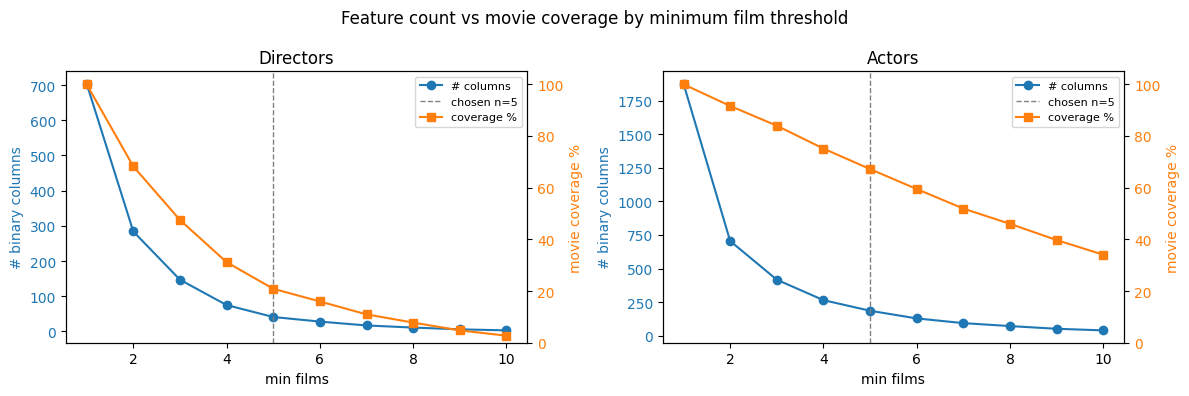

Using MIN_DIRECTOR_FILMS=5, MIN_ACTOR_FILMS=5


In [7]:
def person_threshold_stats(counts, movie_hit_fn, thresholds=range(1, 11)):
    rows = []
    for n in thresholds:
        kept = counts[counts >= n].index
        rows.append(
            {
                "min_films": n,
                "n_people": int(len(kept)),
                "coverage": float(movie_hit_fn(kept).mean()),
            }
        )
    return pd.DataFrame(rows)


def director_covered(kept):
    return df["director"].isin(kept)


def actor_covered(kept):
    return df[["actor_1", "actor_2", "actor_3"]].isin(kept).any(axis=1)


# Chosen defaults (edit after inspecting the panel)
MIN_DIRECTOR_FILMS = 5
MIN_ACTOR_FILMS = 5

dir_thresh = person_threshold_stats(dir_counts, director_covered)
actor_thresh = person_threshold_stats(actor_counts, actor_covered)

summary = dir_thresh.merge(
    actor_thresh, on="min_films", suffixes=("_director", "_actor")
)
summary["coverage_director"] = (summary["coverage_director"] * 100).round(1)
summary["coverage_actor"] = (summary["coverage_actor"] * 100).round(1)
summary = summary.rename(
    columns={
        "n_people_director": "n_directors",
        "n_people_actor": "n_actors",
        "coverage_director": "coverage_director_%",
        "coverage_actor": "coverage_actor_%",
    }
)
display(summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

for ax, table, chosen, title in [
    (axes[0], dir_thresh, MIN_DIRECTOR_FILMS, "Directors"),
    (axes[1], actor_thresh, MIN_ACTOR_FILMS, "Actors"),
]:
    ax.plot(table["min_films"], table["n_people"], marker="o", color="C0", label="# columns")
    ax.set_xlabel("min films")
    ax.set_ylabel("# binary columns", color="C0")
    ax.tick_params(axis="y", labelcolor="C0")
    ax.axvline(chosen, color="gray", linestyle="--", linewidth=1, label=f"chosen n={chosen}")

    ax2 = ax.twinx()
    ax2.plot(
        table["min_films"],
        table["coverage"] * 100,
        marker="s",
        color="C1",
        label="coverage %",
    )
    ax2.set_ylabel("movie coverage %", color="C1")
    ax2.tick_params(axis="y", labelcolor="C1")
    ax2.set_ylim(0, 105)

    ax.set_title(title)
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=8)

fig.suptitle("Feature count vs movie coverage by minimum film threshold")
fig.tight_layout()
plt.show()

print(
    f"Using MIN_DIRECTOR_FILMS={MIN_DIRECTOR_FILMS}, MIN_ACTOR_FILMS={MIN_ACTOR_FILMS}"
)

In [8]:
# directors / actors at chosen minima
top_directors = dir_counts[dir_counts >= MIN_DIRECTOR_FILMS].index.tolist()
director_cols = {
    f"director_{slugify(d)}": (df["director"] == d).astype(int) for d in top_directors
}
feature_blocks.append(pd.DataFrame(director_cols, index=df.index))
print(f"directors (>= {MIN_DIRECTOR_FILMS} films): {len(top_directors)}")

top_actors = actor_counts[actor_counts >= MIN_ACTOR_FILMS].index.tolist()
actor_cols = {
    f"actor_{slugify(a)}": df[["actor_1", "actor_2", "actor_3"]]
    .isin([a])
    .any(axis=1)
    .astype(int)
    for a in top_actors
}
feature_blocks.append(pd.DataFrame(actor_cols, index=df.index))
print(f"actors (>= {MIN_ACTOR_FILMS} films): {len(top_actors)}")

cat_features = pd.concat(feature_blocks, axis=1)
print("categorical feature columns:", cat_features.shape[1])

directors (>= 5 films): 41
actors (>= 5 films): 186
categorical feature columns: 290


## 7. Assemble feature table and save

Keep IDs, title, engineered numeric columns (raw + scaled), and categorical encodings. Drop raw JSON and intermediate name lists.

In [9]:
KEEP_BASE = [
    "netflix_movie_id",
    "tmdb_id",
    "title",
    "year",
    "movie_age",
    "runtime",
    "budget_log",
    "revenue_log",
    "log_roi",
    "budget_log_scaled",
    "revenue_log_scaled",
    "runtime_scaled",
    "year_scaled",
    "log_roi_scaled",
]

features = pd.concat([df[KEEP_BASE], cat_features], axis=1)

print("shape:", features.shape)
print("null count:", int(features.isna().sum().sum()))
print("columns (first 25):", list(features.columns[:25]))
features.head(2)

shape: (1322, 303)
null count: 0
columns (first 25): ['netflix_movie_id', 'tmdb_id', 'title', 'year', 'runtime', 'budget_log', 'revenue_log', 'log_roi', 'budget_log_scaled', 'revenue_log_scaled', 'runtime_scaled', 'year_scaled', 'log_roi_scaled', 'lang_en', 'is_multilingual', 'decade_1910', 'decade_1920', 'decade_1930', 'decade_1940', 'decade_1950', 'decade_1960', 'decade_1970', 'decade_1980', 'decade_1990', 'decade_2000']


,netflix_movie_id,tmdb_id,title,year,runtime,budget_log,revenue_log,log_roi,budget_log_scaled,revenue_log_scaled,...,actor_benjamin_bratt,actor_robin_wright,actor_philip_seymour_hoffman,actor_diane_lane,actor_t_a_leoni,actor_lucy_liu,actor_john_turturro,actor_taye_diggs,actor_will_patton,actor_courteney_cox
1,30,6964,Something's Gotta Give,2003.0,128.0,18.197537,19.401743,1.204206,0.906038,1.020333,...,0,0,0,0,0,0,0,0,0,0
2,55,11863,Jade,1995.0,95.0,17.727534,16.103146,-1.624388,0.619650,-0.762311,...,0,0,0,0,0,0,0,0,0,0


In [10]:
out_path = ROOT / "data/processed/movies_features.csv"
features.to_csv(out_path, index=False)
print(f"saved {out_path} ({features.shape[0]} rows x {features.shape[1]} cols)")

saved ..\data\processed\movies_features.csv (1322 rows x 303 cols)
